In [ ]:
import sys

print(sys.executable)

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ert_visualization.io import (
    read_electrode_elevations,
    read_ert_xyz,
)

In [2]:
# Find the repository root regardless of whether the notebook
# is launched from the project root or the notebooks directory.

if Path.cwd().name == "notebooks":
    PROJECT_ROOT = Path.cwd().parent
else:
    PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
FIGURE_DIR = PROJECT_ROOT / "figures"
INTERACTIVE_DIR = PROJECT_ROOT / "interactive"

FIGURE_DIR.mkdir(exist_ok=True)
INTERACTIVE_DIR.mkdir(exist_ok=True)

In [3]:
survey_files = {
    "Wenner Day 1": RAW_DATA_DIR / "Wenner_Day1.xyz",
    "Dipole-Dipole Day 1": RAW_DATA_DIR / "Dipole_Dipole_Day1.xyz",
    "Wenner Day 2": RAW_DATA_DIR / "Wenner_Day2.xyz",
    "Dipole-Dipole Day 2": RAW_DATA_DIR / "Dipole_Dipole_Day2.xyz",
}

ert_data = {
    survey_name: read_ert_xyz(filepath)
    for survey_name, filepath in survey_files.items()
}

In [4]:
for survey_name, df in ert_data.items():
    print(f"{survey_name}")
    print(f"  Model blocks: {len(df)}")
    print(
        f"  Profile distance: "
        f"{df['x_m'].min():.1f}–{df['x_m'].max():.1f} m"
    )
    print(
        f"  Maximum depth: "
        f"{df['depth_positive_m'].max():.1f} m"
    )
    print(
        f"  Resistivity: "
        f"{df['resistivity_ohm_m'].min():.2f}–"
        f"{df['resistivity_ohm_m'].max():.2f} Ω·m"
    )
    print()

Wenner Day 1
  Model blocks: 748
  Profile distance: 6.0–314.0 m
  Maximum depth: 52.5 m
  Resistivity: 5.45–35794.00 Ω·m

Dipole-Dipole Day 1
  Model blocks: 977
  Profile distance: 6.0–394.0 m
  Maximum depth: 45.9 m
  Resistivity: 0.62–1327537.00 Ω·m

Wenner Day 2
  Model blocks: 644
  Profile distance: 4.5–229.5 m
  Maximum depth: 29.9 m
  Resistivity: 1.96–156818.00 Ω·m

Dipole-Dipole Day 2
  Model blocks: 727
  Profile distance: 4.5–235.5 m
  Maximum depth: 34.4 m
  Resistivity: 0.55–293065.00 Ω·m



In [5]:
elevation_data = read_electrode_elevations(
    DATA_DIR / "electrode_elevations.csv"
)

day1_elevation = elevation_data[
    elevation_data["line"] == "Day1"
].copy()

day2_elevation = elevation_data[
    elevation_data["line"] == "Day2"
].copy()

In [6]:
for survey_name, df in ert_data.items():
    print(
        f"{survey_name}: "
        f"{df['x_m'].min():.1f} to {df['x_m'].max():.1f} m"
    )

print()
print(
    "Day 1 elevation data: "
    f"{day1_elevation['x_m'].min():.1f} to "
    f"{day1_elevation['x_m'].max():.1f} m"
)

print(
    "Day 2 elevation data: "
    f"{day2_elevation['x_m'].min():.1f} to "
    f"{day2_elevation['x_m'].max():.1f} m"
)

Wenner Day 1: 6.0 to 314.0 m
Dipole-Dipole Day 1: 6.0 to 394.0 m
Wenner Day 2: 4.5 to 229.5 m
Dipole-Dipole Day 2: 4.5 to 235.5 m

Day 1 elevation data: 0.0 to 320.0 m
Day 2 elevation data: 0.0 to 240.0 m


### Survey geometry note

Day 1 and Day 2 were collected along perpendicular profiles with different electrode spacing. The Day 1 elevation data span 0–320 m, while the Dipole-Dipole Day 1 inversion model extends to approximately 394 m. Because the horizontal coordinates do not directly match the available topographic profile, topographic correction is not applied to the Dipole-Dipole Day 1 section until the coordinate relationship is verified.

In [7]:
from ert_visualization.io import (
    read_electrode_elevations,
    read_ert_xyz,
)

from ert_visualization.processing import (
    add_topography_to_model,
    interpolate_ert_grid,
    validate_topography_coverage,
)

from ert_visualization.plotting import (
    plot_ert_comparison,
    plot_ert_section,
)

In [8]:
wenner_day1_topo = add_topography_to_model(
    ert_data["Wenner Day 1"],
    day1_elevation,
)

wenner_day1_topo[
    [
        "x_m",
        "depth_positive_m",
        "surface_elevation_m",
        "model_elevation_m",
    ]
].head()

,x_m,depth_positive_m,surface_elevation_m,model_elevation_m
0,6.0,1.0,1252.248820,1251.248820
1,10.0,1.0,1252.106825,1251.106825
2,14.0,1.0,1251.930560,1250.930560
3,18.0,1.0,1251.765620,1250.765620
4,22.0,1.0,1251.668640,1250.668640


In [9]:
wenner_day2_topo = add_topography_to_model(
    ert_data["Wenner Day 2"],
    day2_elevation,
)

dipole_day2_topo = add_topography_to_model(
    ert_data["Dipole-Dipole Day 2"],
    day2_elevation,
)

In [10]:
dipole_day1_topo = add_topography_to_model(
    ert_data["Dipole-Dipole Day 1"],
    day1_elevation,
)

ValueError: Topography data does not cover the ERT survey area. ERT model spans 6.0 - 394.0 m, but elevation data spans 0.0 - 320.0 m.

In [11]:
XI, ZI, RHOI = interpolate_ert_grid(
    ert_data["Wenner Day 1"]
)

In [12]:
print("XI shape:", XI.shape)
print("ZI shape:", ZI.shape)
print("RHOI shape:", RHOI.shape)

XI shape: (200, 400)
ZI shape: (200, 400)
RHOI shape: (200, 400)


In [13]:
XI_topo, ZI_topo, RHOI_topo = interpolate_ert_grid(
    wenner_day1_topo,
    vertical_column="model_elevation_m",
)

In [14]:
print(XI_topo.shape)
print(ZI_topo.shape)
print(RHOI_topo.shape)

(200, 400)
(200, 400)
(200, 400)


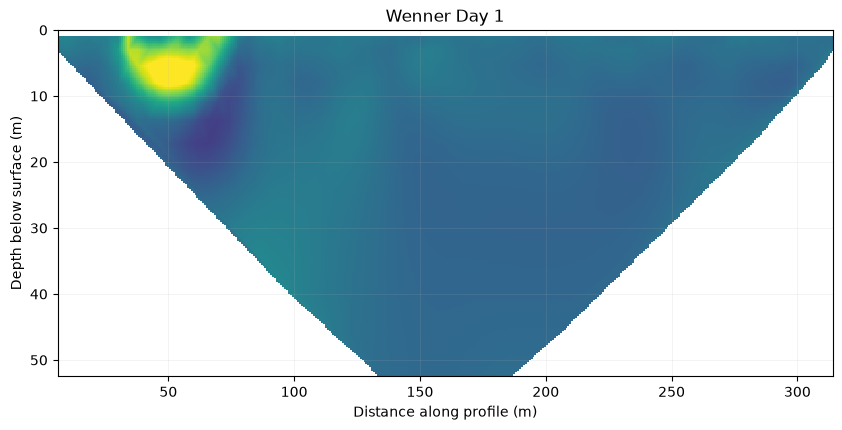

In [15]:
fig, ax, mesh = plot_ert_section(
    ert_data["Wenner Day 1"],
    title="Wenner Day 1",
)

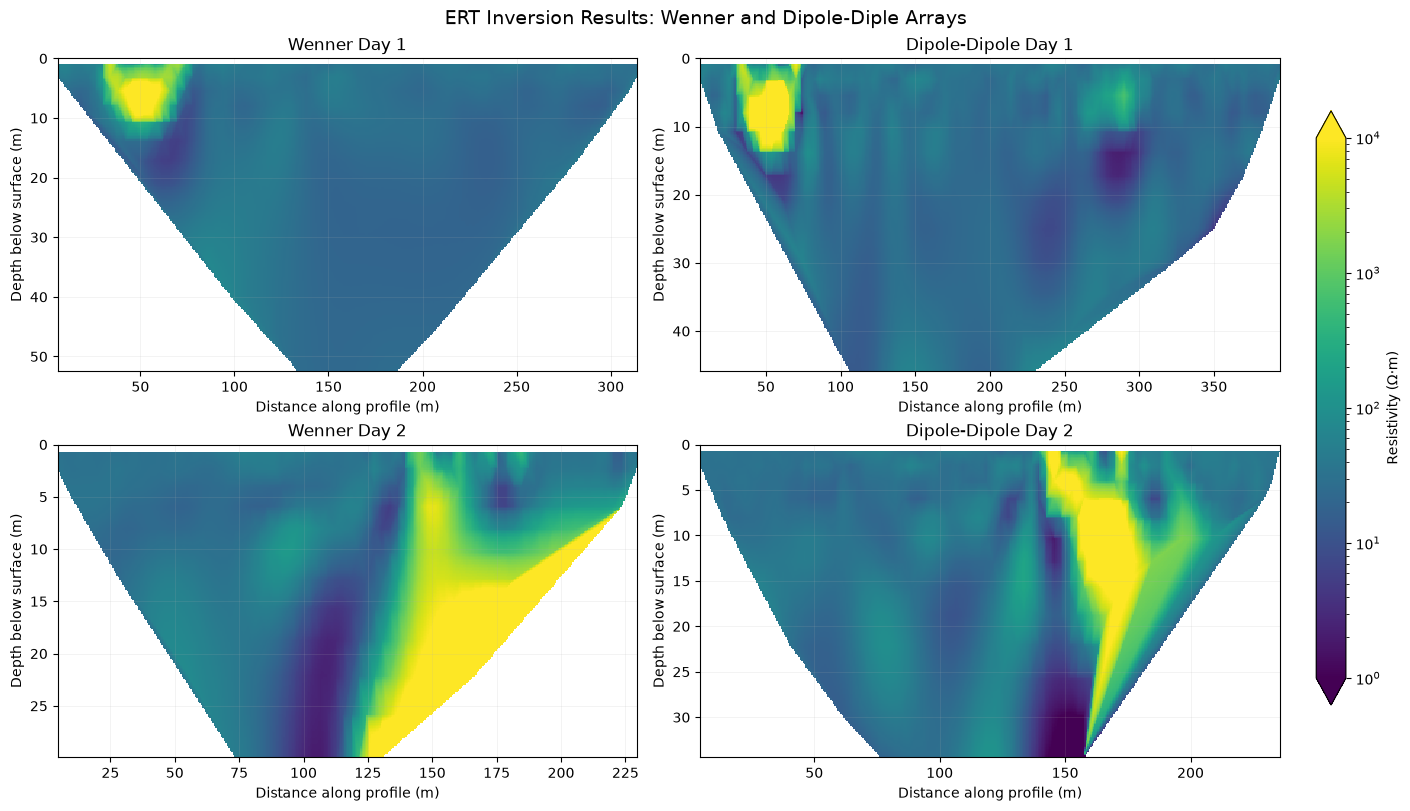

In [16]:
comparison_fig = plot_ert_comparison(
    ert_data
)

In [17]:
vmin = 5.0
vmax = 1000.0

for survey_name, df in ert_data.items():
    resistivity = df["resistivity_ohm_m"]

    below = (resistivity < vmin).sum()
    within = (
        (resistivity >= vmin)
        & (resistivity <= vmax)
    ).sum()
    above = (resistivity > vmax).sum()

    total = len(resistivity)

    print(survey_name)
    print(
        f"  Below {vmin:g} Ω·m: "
        f"{below} ({100 * below / total:.1f}%)"
    )
    print(
        f"  Between {vmin:g} and {vmax:g} Ω·m: "
        f"{within} ({100 * within / total:.1f}%)"
    )
    print(
        f"  Above {vmax:g} Ω·m: "
        f"{above} ({100 * above / total:.1f}%)"
    )
    print()

Wenner Day 1
  Below 5 Ω·m: 0 (0.0%)
  Between 5 and 1000 Ω·m: 722 (96.5%)
  Above 1000 Ω·m: 26 (3.5%)

Dipole-Dipole Day 1
  Below 5 Ω·m: 17 (1.7%)
  Between 5 and 1000 Ω·m: 930 (95.2%)
  Above 1000 Ω·m: 30 (3.1%)

Wenner Day 2
  Below 5 Ω·m: 25 (3.9%)
  Between 5 and 1000 Ω·m: 532 (82.6%)
  Above 1000 Ω·m: 87 (13.5%)

Dipole-Dipole Day 2
  Below 5 Ω·m: 25 (3.4%)
  Between 5 and 1000 Ω·m: 638 (87.8%)
  Above 1000 Ω·m: 64 (8.8%)



In [18]:
def ordinal(number: int) -> str:
    if 10 <= number % 100 <= 20:
        suffix = "th"

    else:
        suffix = {
            1: "st",
            2: "nd",
            3: "rd",
        }.get(number % 10, "th")

    return f"{number}{suffix}"


percentiles = [
    1,
    2,
    5,
    25,
    50,
    75,
    95,
    98,
    99,
]


for survey_name, df in ert_data.items():
    resistivity = df["resistivity_ohm_m"]

    print(survey_name)

    for percentile in percentiles:
        value = np.percentile(
            resistivity,
            percentile,
        )

        print(
            f"  {ordinal(percentile):>4} percentile: "
            f"{value:,.2f} Ω·m"
        )

    print()

Wenner Day 1
   1st percentile: 7.77 Ω·m
   2nd percentile: 9.96 Ω·m
   5th percentile: 16.66 Ω·m
  25th percentile: 21.16 Ω·m
  50th percentile: 26.77 Ω·m
  75th percentile: 36.57 Ω·m
  95th percentile: 202.71 Ω·m
  98th percentile: 2,931.58 Ω·m
  99th percentile: 9,717.12 Ω·m

Dipole-Dipole Day 1
   1st percentile: 3.63 Ω·m
   2nd percentile: 5.80 Ω·m
   5th percentile: 10.04 Ω·m
  25th percentile: 20.84 Ω·m
  50th percentile: 27.50 Ω·m
  75th percentile: 38.39 Ω·m
  95th percentile: 144.64 Ω·m
  98th percentile: 4,089.92 Ω·m
  99th percentile: 25,856.88 Ω·m

Wenner Day 2
   1st percentile: 2.54 Ω·m
   2nd percentile: 3.07 Ω·m
   5th percentile: 6.09 Ω·m
  25th percentile: 25.48 Ω·m
  50th percentile: 38.08 Ω·m
  75th percentile: 95.75 Ω·m
  95th percentile: 6,885.85 Ω·m
  98th percentile: 22,822.00 Ω·m
  99th percentile: 38,139.18 Ω·m

Dipole-Dipole Day 2
   1st percentile: 0.95 Ω·m
   2nd percentile: 2.68 Ω·m
   5th percentile: 8.77 Ω·m
  25th percentile: 26.20 Ω·m
  50th percentil

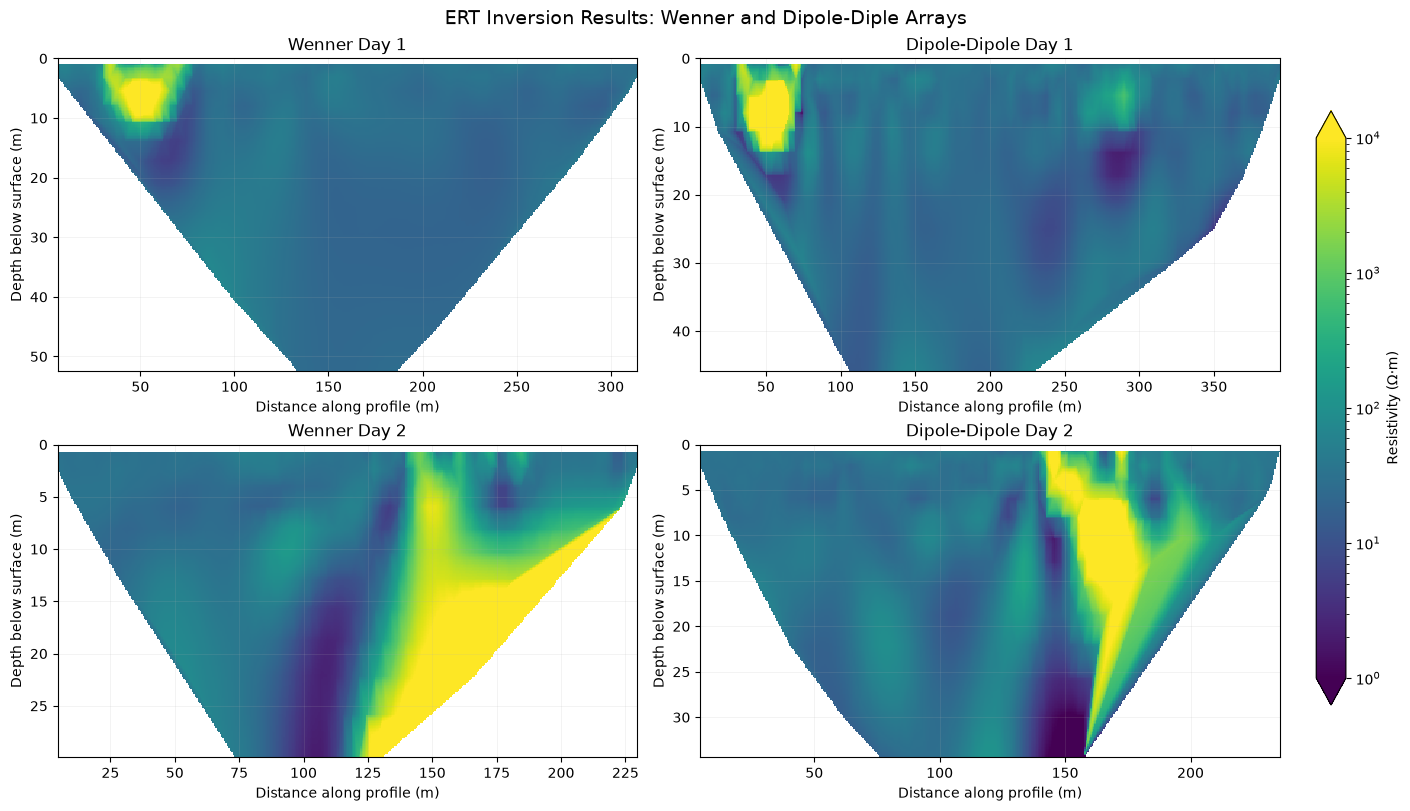

In [19]:
linear_fig = plot_ert_comparison(
    ert_data,
    interpolation_space="linear",
)

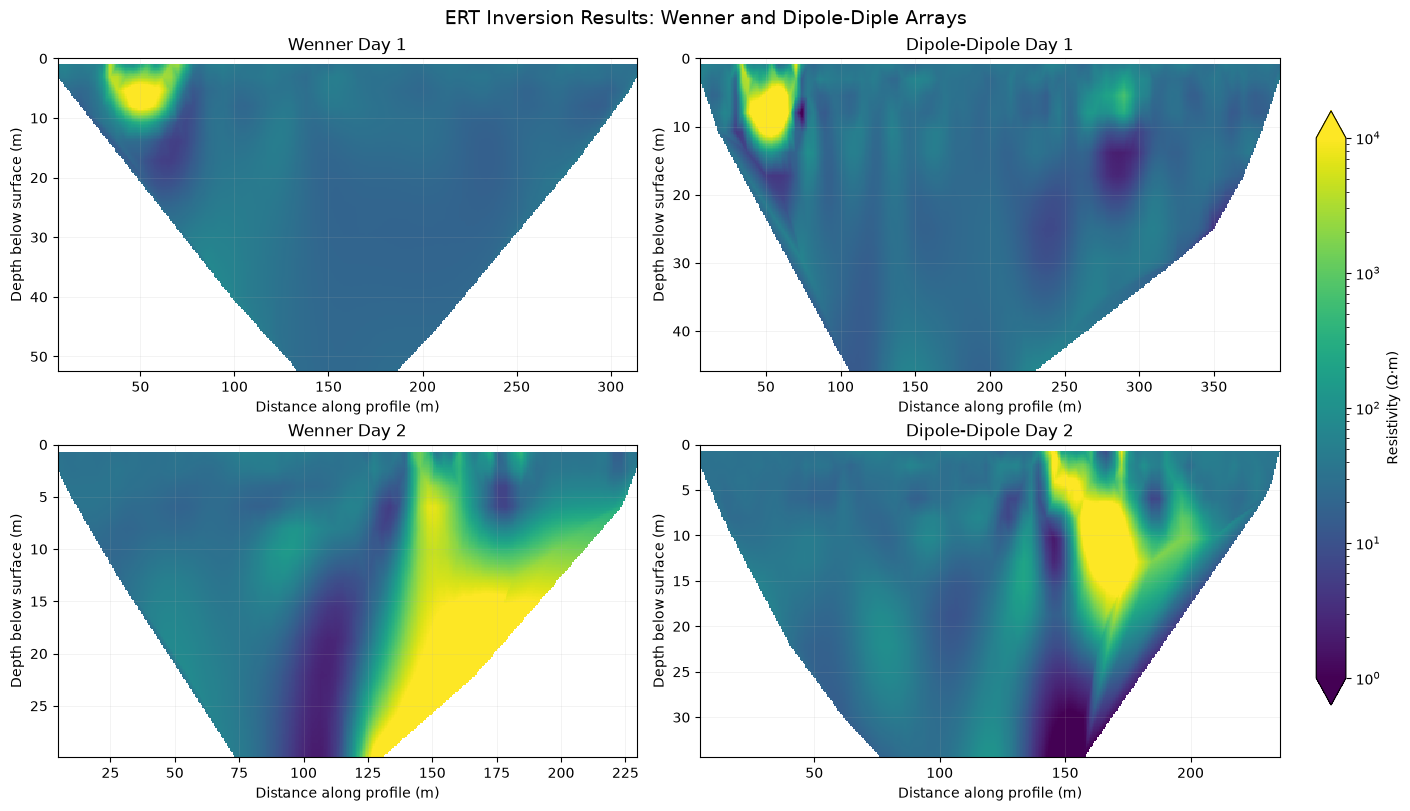

In [20]:
log_fig = plot_ert_comparison(
    ert_data,
    interpolation_space="log10",
)

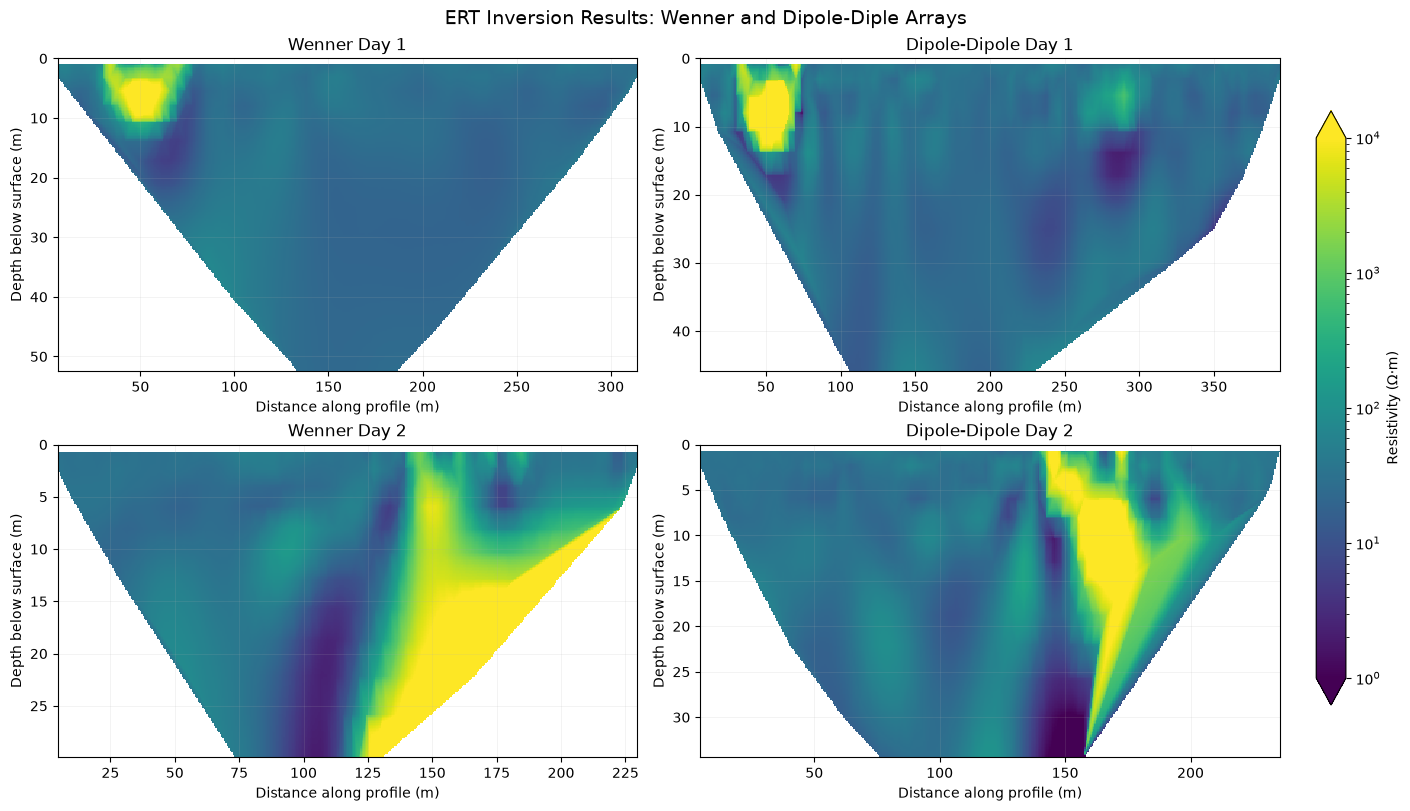

In [21]:
comparison_fig = plot_ert_comparison(
    ert_data
)